In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    make_scorer
)

import joblib

# 1. Business Understanding

## Goal

The goal of this project is to estimate a developer's annual salary in USD using structured information from the Stack Overflow Developer Survey.

This notebook represents **Model Iteration 2**.

Compared with the first basic iteration, this iteration:

1. Keeps a much broader range of suitable structured features.
2. Removes identifiers, salary leakage, preference-based fields and open-text fields.
3. Separates multi-select answers before encoding.
4. Applies one-hot encoding to categorical features.
5. Applies StandardScaler before PCA.
6. Uses PCA to reduce the expanded feature space while retaining 95% of its variance.
7. Compares raw-salary and log-salary model versions.

PCA is tested as an improvement rather than assumed to be the final solution. Its performance will be compared using the same regression metrics as the earlier iteration.

# 2. Data Understanding

## 2.1 Load Dataset

In [2]:
## Read survey data into pandas DataFrame
FILE_PATH = "results.csv"

df = pd.read_csv(
    FILE_PATH,
    low_memory=False
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (49191, 172)


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


In [4]:
## Check for missing data
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (
        df.isna().mean() * 100
    ).round(2)
}).sort_values(
    "Missing Percentage",
    ascending=False
)

missing_summary.head(20)

,Missing Values,Missing Percentage
AIAgentObsWrite,48927,99.46
SOTagsWant Entry,48761,99.13
SOTagsHaveEntry,48733,99.07
AIModelsWantEntry,48716,99.03
AIAgentOrchWrite,48713,99.03
JobSatPoints_15_TEXT,48527,98.65
AIAgentKnowWrite,48425,98.44
AIModelsHaveEntry,48415,98.42
SO_Actions_15_TEXT,48368,98.33
AIAgentExtWrite,48332,98.25


In [5]:
## Describe the target distribution
target_column = "ConvertedCompYearly"

df[target_column] = pd.to_numeric(
    df[target_column],
    errors="coerce"
)

df[target_column].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
90%      1.840000e+05
95%      2.320290e+05
99%      4.408560e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

## 2.3 Data Visualisation

### 2.3.1 Salary Distribution

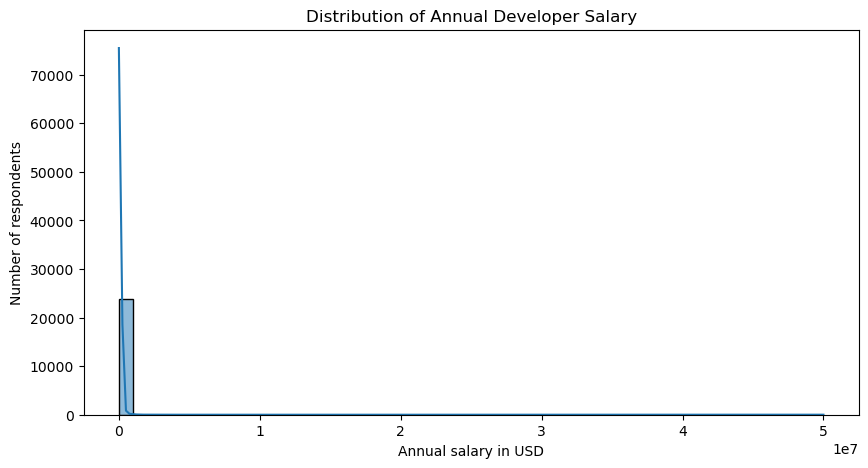

In [6]:
## Display the original salary distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    df[target_column].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Annual Developer Salary")
plt.xlabel("Annual salary in USD")
plt.ylabel("Number of respondents")
plt.show()

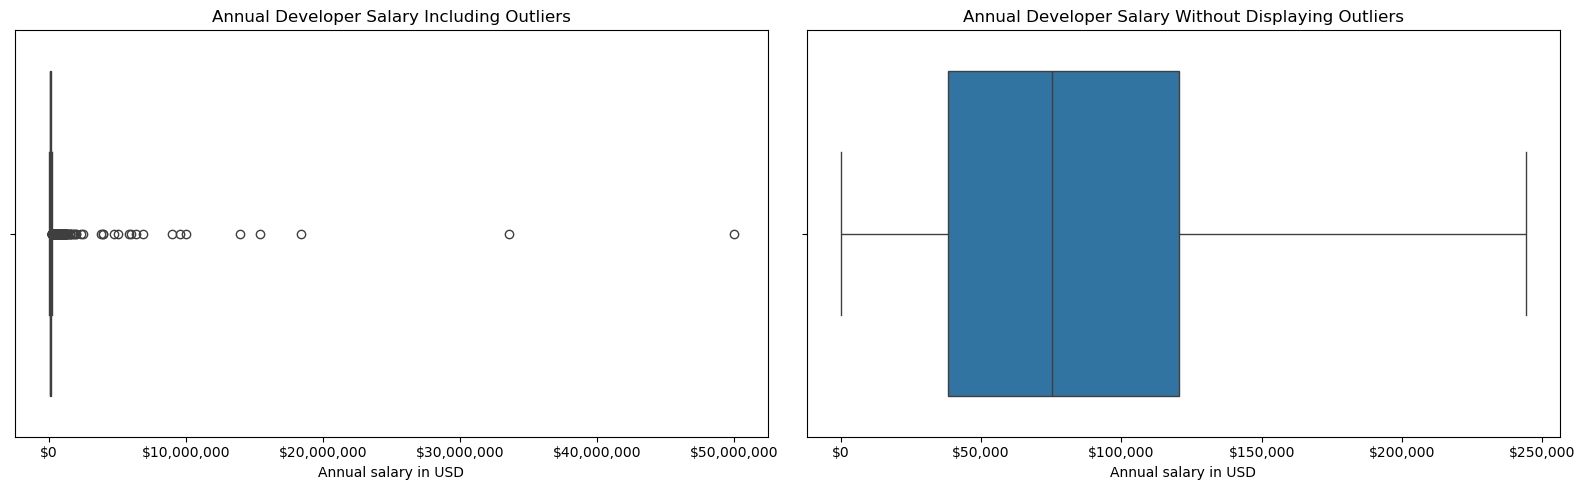

In [7]:
## Compare the complete distribution with the typical salary range
from matplotlib.ticker import StrMethodFormatter

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)

sns.boxplot(
    x=df[target_column],
    ax=axes[0]
)

axes[0].set_title(
    "Annual Developer Salary Including Outliers"
)
axes[0].set_xlabel(
    "Annual salary in USD"
)
axes[0].xaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

sns.boxplot(
    x=df[target_column],
    showfliers=False,
    ax=axes[1]
)

axes[1].set_title(
    "Annual Developer Salary Without Displaying Outliers"
)
axes[1].set_xlabel(
    "Annual salary in USD"
)
axes[1].xaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.show()

# 3. Data Preparation

## 3.1 Define the Modelling Population

In [8]:
## Create a separate copy so that the original DataFrame remains unchanged
model_df = df.copy()

## Check the salary values before filtering
salary_checks = pd.Series({
    "Missing salary": model_df[target_column].isna().sum(),
    "Zero salary": (model_df[target_column] == 0).sum(),
    "Negative salary": (model_df[target_column] < 0).sum(),
    "Salary above USD 1 million": (
        model_df[target_column] > 1_000_000
    ).sum()
})

salary_checks

Missing salary                25244
Zero salary                       0
Negative salary                   0
Salary above USD 1 million       46
dtype: int64

In [9]:
## Keep employed respondents with a positive reported salary
##
## Zero and negative values are excluded because the application
## estimates positive annual compensation for paid employment.
##
## Large positive salaries are not automatically removed because
## they may still be valid. Their influence will later be reduced
## through a log-target experiment.

model_df = model_df[
    model_df["Employment"].eq("Employed")
    & model_df[target_column].notna()
    & (model_df[target_column] > 0)
].copy()

print(
    "Rows remaining for modelling:",
    len(model_df)
)

Rows remaining for modelling: 19500


## 3.2 Inspect Questionable Values

In [10]:
## Convert known numeric-like survey columns
numeric_like_columns = [
    "YearsCode",
    "WorkExp",
    "ToolCountWork",
    "ToolCountPersonal",
    "JobSat"
]

numeric_like_columns += [
    column
    for column in model_df.columns
    if column.startswith("JobSatPoints_")
]

for column in numeric_like_columns:
    if column in model_df.columns:
        model_df[column] = model_df[column].replace({
            "Less than 1 year": 0.5,
            "More than 50 years": 51
        })

        model_df[column] = pd.to_numeric(
            model_df[column],
            errors="coerce"
        )

In [11]:
## Flag unusual responses for investigation
## These records are not automatically deleted

model_df["QualityFlag"] = ""

if "YearsCode" in model_df.columns:
    model_df.loc[
        model_df["YearsCode"] > 70,
        "QualityFlag"
    ] += "Unusually high YearsCode; "

if "WorkExp" in model_df.columns:
    model_df.loc[
        model_df["WorkExp"] > 70,
        "QualityFlag"
    ] += "Unusually high WorkExp; "

model_df.loc[
    model_df[target_column] > 1_000_000,
    "QualityFlag"
] += "Salary above USD 1 million; "

quality_review = model_df[
    model_df["QualityFlag"] != ""
][
    [
        column
        for column in [
            "ResponseId",
            "YearsCode",
            "WorkExp",
            target_column,
            "QualityFlag"
        ]
        if column in model_df.columns
    ]
]

print(
    "Rows flagged for review:",
    len(quality_review)
)

quality_review.head(20)

Rows flagged for review: 39


,ResponseId,YearsCode,WorkExp,ConvertedCompYearly,QualityFlag
2009,2010,25.0,14.0,1006403.0,Salary above USD 1 million;
2668,2669,25.0,23.0,1300000.0,Salary above USD 1 million;
2725,2726,17.0,13.0,1250000.0,Salary above USD 1 million;
2812,2813,24.0,19.0,1200000.0,Salary above USD 1 million;
3265,3266,30.0,23.0,1500000.0,Salary above USD 1 million;
4583,4584,30.0,30.0,1160147.0,Salary above USD 1 million;
4842,4843,25.0,25.0,1100000.0,Salary above USD 1 million;
5327,5328,22.0,11.0,1950000.0,Salary above USD 1 million;
5410,5411,18.0,11.0,2346000.0,Salary above USD 1 million;
9310,9311,7.0,6.0,1500000.0,Salary above USD 1 million;


# 4. Model Iteration 4 – Broad Usable Feature Set

Iteration 3 deliberately used only 14 meaningful original features.

Iteration 4 tests the opposite approach by keeping nearly every usable
numerical and single-answer categorical column.

The following are excluded:

1. Identifiers and salary-leakage columns.
2. Desired, admired and preference-based technology columns.
3. Open-text survey responses.
4. Columns with more than 85% missing values.
5. Columns containing only one unique value.
6. Multi-select columns containing semicolon-separated answers.

Multi-select fields are not considered useless. They are excluded because
ordinary one-hot encoding would treat each complete answer combination as a
separate category, while multi-hot encoding was unstable in the earlier
experiment.

PCA is not used because Iteration 3 showed that the no-PCA model performed
better. The log-transformed salary target is retained.


## 4.1 Remove Truly Unsuitable Columns


In [12]:
## Direct exclusions

direct_exclusions_iter4 = [
    "ResponseId",
    "Currency",
    "CompTotal",
    target_column,
    "QualityFlag"
]


## Remove admired, desired and open-text columns

excluded_keywords_iter4 = [
    "_TEXT",
    "Admired",
    "WantTo",
    "WantEntry",
    "Choice"
]


## Explicit AI open-ended response columns

ai_open_text_columns_iter4 = [
    "AIAgentKnowledge",
    "AIAgentKnowWrite",
    "AIAgentOrchestration",
    "AIAgentOrchWrite",
    "AIAgentObserveSecure",
    "AIAgentObsWrite",
    "AIAgentExternal",
    "AIAgentExtWrite",
    "AIHuman",
    "AIOpen"
]


candidate_features_iter4 = []


for column in model_df.columns:

    if column in direct_exclusions_iter4:
        continue

    if column in ai_open_text_columns_iter4:
        continue

    if any(
        keyword in column
        for keyword in excluded_keywords_iter4
    ):
        continue

    candidate_features_iter4.append(column)


print(
    "Initial broad candidate features:",
    len(candidate_features_iter4)
)


Initial broad candidate features: 123


## 4.2 Exclude Multi-Select Fields


In [13]:
## Identify fields containing semicolon-separated responses.
##
## These fields are excluded from this iteration because
## ordinary one-hot encoding would encode complete combinations,
## while multi-hot encoding was unsuccessful previously.

multi_select_columns_iter4 = []


for column in candidate_features_iter4:

    if model_df[column].dtype != "object":
        continue

    contains_semicolon = (
        model_df[column]
        .dropna()
        .astype(str)
        .str.contains(
            ";",
            regex=False
        )
        .any()
    )

    if contains_semicolon:
        multi_select_columns_iter4.append(column)


print(
    "Multi-select columns excluded:",
    len(multi_select_columns_iter4)
)

print(
    multi_select_columns_iter4
)


Multi-select columns excluded: 39
['EmploymentAddl', 'LearnCode', 'AILearnHow', 'LanguageHaveWorkedWith', 'LanguagesHaveEntry', 'DatabaseHaveWorkedWith', 'DatabaseHaveEntry', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith', 'DevEnvsHaveWorkedWith', 'DevEnvHaveEntry', 'SOTagsHaveWorkedWith', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'CommPlatformHaveWorkedWith', 'CommPlatformHaveEntr', 'CommPlatformWantEntr', 'AIModelsHaveWorkedWith', 'SO_Dev_Content', 'AIToolCurrently partially AI', "AIToolDon't plan to use AI for this task", 'AIToolPlan to partially use AI', 'AIToolPlan to mostly use AI', 'AIToolCurrently mostly AI', 'AIFrustration', 'AIExplain', 'AIAgent_Uses', 'AgentUsesGeneral', 'AIAgentImpactSomewhat agree', 'AIAgentImpactNeutral', 'AIAgentImpactSomewhat disagree', 'AIAgentImpactStrongly agree', 'AIAgentImpactStrongly disagree', 'AIAgentChallengesNeutral', 'AIAgentChallengesSomewhat disagree', 'AIAgentChallengesStrongly agree', 'AIAgentChal

## 4.3 Remove Mostly Missing and Constant Columns


In [14]:
## Create the broad feature DataFrame

X_iter4 = model_df[
    candidate_features_iter4
].copy()

y_iter4 = model_df[
    target_column
].copy()


## Remove multi-select columns

X_iter4 = X_iter4.drop(
    columns=multi_select_columns_iter4
)


## Remove columns with more than 85% missing values

mostly_missing_iter4 = [
    column
    for column in X_iter4.columns
    if X_iter4[column].isna().mean() > 0.85
]


## Remove columns with only one unique value

constant_columns_iter4 = [
    column
    for column in X_iter4.columns
    if X_iter4[column].nunique(
        dropna=True
    ) <= 1
]


columns_removed_iter4 = list(
    set(
        mostly_missing_iter4
        + constant_columns_iter4
    )
)


X_iter4 = X_iter4.drop(
    columns=columns_removed_iter4
)


print(
    "Mostly missing columns removed:",
    len(mostly_missing_iter4)
)

print(
    "Constant columns removed:",
    len(constant_columns_iter4)
)

print(
    "Original columns retained before OHE:",
    X_iter4.shape[1]
)


Mostly missing columns removed: 6
Constant columns removed: 1
Original columns retained before OHE: 77


In [15]:
## Display all retained original columns

print(
    X_iter4.columns.tolist()
)


['MainBranch', 'Age', 'EdLevel', 'WorkExp', 'LearnCodeChoose', 'LearnCodeAI', 'YearsCode', 'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'PurchaseInfluence', 'TechEndorseIntro', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'TechOppose_15', 'Industry', 'JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15', 'JobSatPoints_16', 'AIThreat', 'NewRole', 'ToolCountWork', 'ToolCountPersonal', 'Country', 'SOAccount', 'SOVisitFreq', 'SODuration', 'SOPartFreq', 'SO_Actions_1', 'SO_Actions_16', 'SO_Actions_3', 'SO_Actions_4', 'SO_Ac

## 4.4 Prepare Missing Values


In [16]:
## Identify numerical and categorical columns

numerical_columns_iter4 = (
    X_iter4
    .select_dtypes(
        include=["number", "bool"]
    )
    .columns
    .tolist()
)

categorical_columns_iter4 = (
    X_iter4
    .select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)


## Fill numerical missing values using medians

numerical_medians_iter4 = {}


for column in numerical_columns_iter4:

    numerical_medians_iter4[column] = (
        X_iter4[column].median()
    )

    X_iter4[column] = (
        X_iter4[column]
        .fillna(
            numerical_medians_iter4[column]
        )
    )


## Fill categorical missing values

for column in categorical_columns_iter4:

    X_iter4[column] = (
        X_iter4[column]
        .fillna("Unknown")
        .astype(str)
    )


print(
    "Numerical columns:",
    len(numerical_columns_iter4)
)

print(
    "Categorical columns:",
    len(categorical_columns_iter4)
)


Numerical columns: 50
Categorical columns: 27


## 4.5 One-Hot Encode the Broad Feature Set


In [17]:
## Apply one-hot encoding to all retained
## single-answer categorical columns

X_encoded_iter4 = pd.get_dummies(
    X_iter4,
    drop_first=True
)


print(
    "Original columns before OHE:",
    X_iter4.shape[1]
)

print(
    "Features after OHE:",
    X_encoded_iter4.shape[1]
)

print(
    "Encoded dataset shape:",
    X_encoded_iter4.shape
)


Original columns before OHE: 77
Features after OHE: 377
Encoded dataset shape: (19500, 377)


## 4.6 Train-Test Split


In [18]:
## Split the broad encoded dataset

x_train_iter4, x_test_iter4, y_train_iter4, y_test_iter4 = (
    train_test_split(
        X_encoded_iter4,
        y_iter4,
        test_size=0.2,
        random_state=676767
    )
)


print(
    "Training feature shape:",
    x_train_iter4.shape
)

print(
    "Testing feature shape:",
    x_test_iter4.shape
)


Training feature shape: (15600, 377)
Testing feature shape: (3900, 377)


# 5. Iteration 4 Modelling

This iteration uses:

- The broad usable feature set.
- No PCA.
- A log-transformed salary target.
- Gradient Boosting.
- The same evaluation metrics used previously.


In [19]:
## Evaluation function

iteration4_results = []


def evaluate_iteration4(
    model_name,
    actual_values,
    predicted_values
):

    predicted_values = np.maximum(
        predicted_values,
        0
    )

    result = {
        "Model": model_name,

        "MAE": mean_absolute_error(
            actual_values,
            predicted_values
        ),

        "Median Absolute Error": (
            median_absolute_error(
                actual_values,
                predicted_values
            )
        ),

        "MSE": mean_squared_error(
            actual_values,
            predicted_values
        ),

        "RMSE": root_mean_squared_error(
            actual_values,
            predicted_values
        ),

        "R2": r2_score(
            actual_values,
            predicted_values
        )
    }

    iteration4_results.append(result)

    return result


## 5.1 Median Baseline


In [20]:
## Train the median baseline

baseline_iter4 = DummyRegressor(
    strategy="median"
)

baseline_iter4.fit(
    x_train_iter4,
    y_train_iter4
)

y_pred_baseline_iter4 = (
    baseline_iter4.predict(
        x_test_iter4
    )
)

evaluate_iteration4(
    "Iteration 4 Median Baseline",
    y_test_iter4,
    y_pred_baseline_iter4
)


{'Model': 'Iteration 4 Median Baseline',
 'MAE': 58726.58974358974,
 'Median Absolute Error': 40826.0,
 'MSE': 19894522047.764614,
 'RMSE': 141047.94237338103,
 'R2': -0.018247690798921967}

## 5.2 Gradient Boosting with Log Target


In [21]:
## Log-transform the training target

y_train_log_iter4 = np.log1p(
    y_train_iter4
)


## Train the broad-feature model without PCA

gradient_iter4 = GradientBoostingRegressor(
    loss="huber",
    random_state=67
)

gradient_iter4.fit(
    x_train_iter4,
    y_train_log_iter4
)


## Convert predictions back into USD

y_pred_gradient_iter4 = np.expm1(
    gradient_iter4.predict(
        x_test_iter4
    )
)


evaluate_iteration4(
    "Iteration 4 Gradient Boosting + Broad Features + Log Target",
    y_test_iter4,
    y_pred_gradient_iter4
)


{'Model': 'Iteration 4 Gradient Boosting + Broad Features + Log Target',
 'MAE': 37030.68171634029,
 'Median Absolute Error': 19554.661066796514,
 'MSE': 16566056050.895113,
 'RMSE': 128709.19178867961,
 'R2': 0.15211090374675196}

## 5.3 Compare the Initial Iteration 4 Models


In [22]:
## Calculate improvement over the baseline

iteration4_comparison = pd.DataFrame(
    iteration4_results
)

baseline_mae_iter4 = iteration4_comparison.loc[
    iteration4_comparison["Model"].eq(
        "Iteration 4 Median Baseline"
    ),
    "MAE"
].iloc[0]

iteration4_comparison[
    "MAE Improvement vs Baseline (%)"
] = (
    (
        baseline_mae_iter4
        - iteration4_comparison["MAE"]
    )
    / baseline_mae_iter4
    * 100
)

iteration4_comparison = (
    iteration4_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
)

iteration4_comparison


,Model,MAE,Median Absolute Error,MSE,RMSE,R2,MAE Improvement vs Baseline (%)
0,Iteration 4 Gradient Boosting + Broad Features...,37030.681716,19554.661067,1.656606e+10,128709.191789,0.152111,36.943926
1,Iteration 4 Median Baseline,58726.589744,40826.000000,1.989452e+10,141047.942373,-0.018248,0.000000


# 6. Hyperparameter Tuning


In [23]:
## Custom scorer for salary predictions in USD

def salary_mae_from_log_iter4(
    actual_log_salary,
    predicted_log_salary
):

    actual_salary = np.expm1(
        actual_log_salary
    )

    predicted_salary = np.expm1(
        predicted_log_salary
    )

    return mean_absolute_error(
        actual_salary,
        predicted_salary
    )


salary_mae_scorer_iter4 = make_scorer(
    salary_mae_from_log_iter4,
    greater_is_better=False
)


## No more than three choices are provided
## for each hyperparameter.

parameter_options_iter4 = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.10],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10]
}


gradient_for_tuning_iter4 = (
    GradientBoostingRegressor(
        loss="huber",
        random_state=67
    )
)


random_search_iter4 = RandomizedSearchCV(
    estimator=gradient_for_tuning_iter4,
    param_distributions=parameter_options_iter4,
    n_iter=10,
    scoring=salary_mae_scorer_iter4,
    cv=3,
    random_state=67,
    n_jobs=-1
)


random_search_iter4.fit(
    x_train_iter4,
    y_train_log_iter4
)


print(
    "Best hyperparameters:"
)

print(
    random_search_iter4.best_params_
)


Best hyperparameters:
{'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 3, 'learning_rate': 0.05}


In [24]:
## Display the tuning logs

tuning_results_iter4 = pd.DataFrame(
    random_search_iter4.cv_results_
)[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

tuning_results_iter4 = (
    tuning_results_iter4
    .sort_values("rank_test_score")
)

tuning_results_iter4.head(10)


,params,mean_test_score,std_test_score,rank_test_score
8,"{'n_estimators': 300, 'min_samples_split': 2, ...",-41511.324619,6230.708222,1
1,"{'n_estimators': 300, 'min_samples_split': 2, ...",-41836.220740,6143.085285,2
3,"{'n_estimators': 100, 'min_samples_split': 5, ...",-42451.183270,6272.766592,3
7,"{'n_estimators': 300, 'min_samples_split': 2, ...",-42798.160959,6252.710955,4
6,"{'n_estimators': 300, 'min_samples_split': 2, ...",-42843.002822,6309.461221,5
9,"{'n_estimators': 100, 'min_samples_split': 5, ...",-43963.638014,6264.232692,6
5,"{'n_estimators': 200, 'min_samples_split': 2, ...",-44054.693469,6301.062785,7
2,"{'n_estimators': 100, 'min_samples_split': 5, ...",-44957.418860,6186.488979,8
4,"{'n_estimators': 200, 'min_samples_split': 5, ...",-45559.915878,6256.915875,9
0,"{'n_estimators': 100, 'min_samples_split': 2, ...",-47662.741939,6309.296291,10


## 6.1 Evaluate the Tuned Broad-Feature Model


In [25]:
## Evaluate the tuned model

best_model_iter4 = (
    random_search_iter4.best_estimator_
)

y_pred_tuned_iter4 = np.expm1(
    best_model_iter4.predict(
        x_test_iter4
    )
)

y_pred_tuned_iter4 = np.maximum(
    y_pred_tuned_iter4,
    0
)


tuned_result_iter4 = {
    "Model": (
        "Iteration 4 Tuned Gradient Boosting + "
        "Broad Features + Log Target"
    ),

    "MAE": mean_absolute_error(
        y_test_iter4,
        y_pred_tuned_iter4
    ),

    "Median Absolute Error": (
        median_absolute_error(
            y_test_iter4,
            y_pred_tuned_iter4
        )
    ),

    "MSE": mean_squared_error(
        y_test_iter4,
        y_pred_tuned_iter4
    ),

    "RMSE": root_mean_squared_error(
        y_test_iter4,
        y_pred_tuned_iter4
    ),

    "R2": r2_score(
        y_test_iter4,
        y_pred_tuned_iter4
    )
}


final_results_iter4 = pd.concat(
    [
        iteration4_comparison.drop(
            columns=[
                "MAE Improvement vs Baseline (%)"
            ],
            errors="ignore"
        ),

        pd.DataFrame(
            [tuned_result_iter4]
        )
    ],
    ignore_index=True
)


final_results_iter4[
    "MAE Improvement vs Baseline (%)"
] = (
    (
        baseline_mae_iter4
        - final_results_iter4["MAE"]
    )
    / baseline_mae_iter4
    * 100
)


final_results_iter4 = (
    final_results_iter4
    .sort_values("MAE")
    .reset_index(drop=True)
)


final_results_iter4


,Model,MAE,Median Absolute Error,MSE,RMSE,R2,MAE Improvement vs Baseline (%)
0,Iteration 4 Tuned Gradient Boosting + Broad Fe...,36116.925938,18498.060427,1.643923e+10,128215.546968,0.158602,38.499875
1,Iteration 4 Gradient Boosting + Broad Features...,37030.681716,19554.661067,1.656606e+10,128709.191789,0.152111,36.943926
2,Iteration 4 Median Baseline,58726.589744,40826.000000,1.989452e+10,141047.942373,-0.018248,0.000000


## 6.2 Broad-Feature Importance


In [26]:
## Display the most influential encoded features

feature_importance_iter4 = pd.DataFrame({
    "Feature": x_train_iter4.columns,

    "Importance": (
        best_model_iter4
        .feature_importances_
    )
}).sort_values(
    "Importance",
    ascending=False
)


feature_importance_iter4.head(20)


,Feature,Importance
300,Country_United States of America,0.329938
1,YearsCode,0.186955
0,WorkExp,0.114240
210,Country_India,0.041576
298,Country_United Kingdom of Great Britain and No...,0.023203
120,RemoteWork_In-person,0.022702
286,Country_Switzerland,0.021826
201,Country_Germany,0.017141
173,Country_Brazil,0.016845
296,Country_Ukraine,0.016580


In [29]:
## Predict salaries for the training data

y_pred_train_iter4 = np.expm1(
    best_model_iter4.predict(
        x_train_iter4
    )
)

y_pred_train_iter4 = np.maximum(
    y_pred_train_iter4,
    0
)


## Compare training and testing results

overfitting_check_iter4 = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],

    "MAE": [
        mean_absolute_error(
            y_train_iter4,
            y_pred_train_iter4
        ),

        mean_absolute_error(
            y_test_iter4,
            y_pred_tuned_iter4
        )
    ],

    "Median Absolute Error": [
        median_absolute_error(
            y_train_iter4,
            y_pred_train_iter4
        ),

        median_absolute_error(
            y_test_iter4,
            y_pred_tuned_iter4
        )
    ],

    "R2": [
        r2_score(
            y_train_iter4,
            y_pred_train_iter4
        ),

        r2_score(
            y_test_iter4,
            y_pred_tuned_iter4
        )
    ]
})


overfitting_check_iter4

,Dataset,MAE,Median Absolute Error,R2
0,Training,40462.230417,18396.142807,0.020077
1,Testing,36116.925938,18498.060427,0.158602


In [31]:
## Compare the salary distributions
## in the training and testing sets

salary_split_comparison = pd.DataFrame({
    "Statistic": [
        "Rows",
        "Minimum",
        "Median",
        "Mean",
        "75th Percentile",
        "95th Percentile",
        "99th Percentile",
        "Maximum"
    ],

    "Training": [
        len(y_train_iter4),
        y_train_iter4.min(),
        y_train_iter4.median(),
        y_train_iter4.mean(),
        y_train_iter4.quantile(0.75),
        y_train_iter4.quantile(0.95),
        y_train_iter4.quantile(0.99),
        y_train_iter4.max()
    ],

    "Testing": [
        len(y_test_iter4),
        y_test_iter4.min(),
        y_test_iter4.median(),
        y_test_iter4.mean(),
        y_test_iter4.quantile(0.75),
        y_test_iter4.quantile(0.95),
        y_test_iter4.quantile(0.99),
        y_test_iter4.max()
    ]
})


salary_split_comparison.style.format({
    "Training": "{:,.0f}",
    "Testing": "{:,.0f}"
})

,Statistic,Training,Testing
0,Rows,"15,600","3,900"
1,Minimum,1,1
2,Median,"79,174","76,752"
3,Mean,"103,623","98,056"
4,75th Percentile,"124,192","124,418"
5,95th Percentile,"235,000","240,000"
6,99th Percentile,"440,000","440,009"
7,Maximum,"33,552,715","6,000,000"


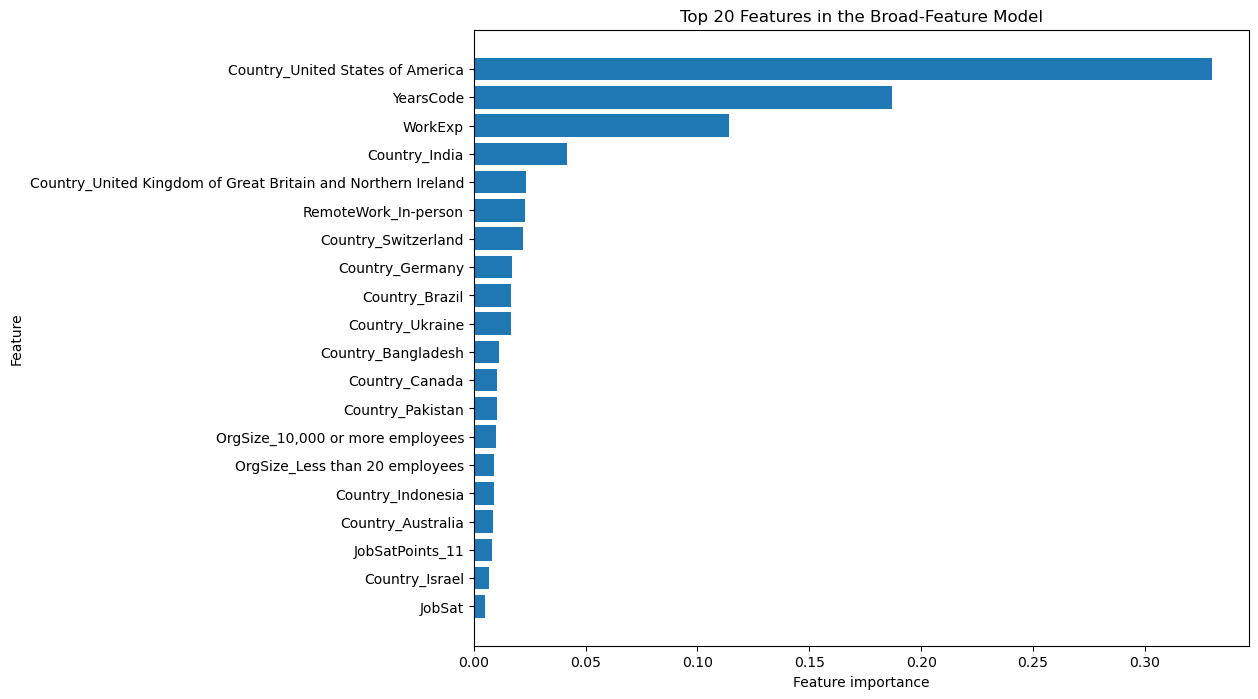

In [27]:
## Plot the 20 most important encoded features

top_features_iter4 = (
    feature_importance_iter4.head(20)
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features_iter4["Feature"][::-1],
    top_features_iter4["Importance"][::-1]
)

plt.title(
    "Top 20 Features in the Broad-Feature Model"
)

plt.xlabel(
    "Feature importance"
)

plt.ylabel(
    "Feature"
)

plt.show()


## 6.3 Save the Broad-Feature Model


In [28]:
## Save the final model and preprocessing information

model_package_iter4 = {
    "model": best_model_iter4,

    "target_transform": "log1p",

    "candidate_features": (
        candidate_features_iter4
    ),

    "multi_select_columns_excluded": (
        multi_select_columns_iter4
    ),

    "columns_removed": (
        columns_removed_iter4
    ),

    "numerical_columns": (
        numerical_columns_iter4
    ),

    "categorical_columns": (
        categorical_columns_iter4
    ),

    "numerical_medians": (
        numerical_medians_iter4
    ),

    "encoded_columns": (
        X_encoded_iter4
        .columns
        .tolist()
    )
}


joblib.dump(
    model_package_iter4,
    "salary_iteration4_broad_model.pkl"
)


print(
    "Saved salary_iteration4_broad_model.pkl"
)


Saved salary_iteration4_broad_model.pkl


# 7. Iteration 4 Improvements and Purpose

Iteration 4 evaluates whether a broader feature set improves prediction
compared with the 14-feature Iteration 3 model.

## Improvements tested

1. **Broad feature coverage**  
   Nearly every usable numerical and single-answer categorical survey field is
   retained.

2. **Removal of genuine leakage and unusable fields**  
   Identifiers, direct compensation inputs, open-text responses, admired
   technologies and desired technologies are excluded.

3. **No multi-hot encoding**  
   Multi-select columns remain excluded because the previous multi-hot
   experiment was unstable.

4. **No PCA**  
   Iteration 3 showed that PCA reduced prediction performance. The broad
   encoded features are therefore passed directly into Gradient Boosting.

5. **Log-transformed target retained**  
   The log target reduces the influence of extremely large salaries.

6. **Direct feature importance**  
   Because PCA is not used, the final feature-importance output remains
   readable.

## Final comparison

The tuned Iteration 4 result should be compared against the tuned Iteration 3
MAE of approximately USD 36,320.

Iteration 4 should only replace Iteration 3 when it produces a lower test MAE
and remains practical to train and deploy.
